# Retrieve chembl data

The purpose of this notebook is to retrieve all compounds on Chembl with measured logd for model training.

In [15]:
from pathlib import Path
import pathlib
import csv

import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

Protein and data variables.

In [16]:
readout = 'LogD7.4'

In [17]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

### Download ligands and bioactivity data from Chembl.

In [18]:
from chembl_webresource_client.new_client import new_client
from tqdm.notebook import tqdm
import concurrent.futures

In [19]:
########## 1. Query all activities ##########

logd_readouts = ['LogD', 'LogD7.4'] # readouts can vary by Chembl version so these may not work for future versions.
all_activities = []

print("Fetching activities...")

for logd_readout in logd_readouts:
    activities = tqdm(new_client.activity.filter(
        standard_type=logd_readout,
        relation='='
    ).only(
        "activity_id",
        "assay_chembl_id",
        "molecule_chembl_id",
        "standard_type",
        "standard_units",
        "relation",
        "standard_value",
        "target_chembl_id"
    ))
    all_activities.extend(activities)

print(f"Total activities fetched: {len(all_activities)}")


Fetching activities...


  0%|          | 0/27337 [00:00<?, ?it/s]

  0%|          | 0/342 [00:00<?, ?it/s]

Total activities fetched: 27679


In [20]:
########## 2. Helper to use the fetched Chembl records to query for all relevant data associated with them ##########

def process_activity(act):
    record = {
        "activity_id": act.get("activity_id"),
        "assay_chembl_id": act.get("assay_chembl_id"),
        "molecule_chembl_id": act.get("molecule_chembl_id"),
        "type": act.get("standard_type"),
        "standard_units": act.get("standard_units"),
        "relation": act.get("relation"),
        "standard_value": act.get("standard_value"),
        "target_chembl_id": act.get("target_chembl_id"),
        # "target_organism": None,
        "assay_description": None,
        "assay_type": None,
        "smiles": None
    }

    try:
        assay = new_client.assay.get(act["assay_chembl_id"])
        record["assay_description"] = assay.get("description")
        record["assay_type"] = assay.get("assay_type")

        molecule = new_client.molecule.get(act["molecule_chembl_id"])
        if molecule and molecule.get("molecule_structures"):
            record["smiles"] = molecule["molecule_structures"].get("canonical_smiles")

        if act.get("target_chembl_id"):
            target = new_client.target.get(act["target_chembl_id"])
            # record["target_organism"] = target.get("organism")

    except Exception as e:
        record["error"] = str(e)

    return record


In [21]:
########## 3. Code to run the query in parallel ##########

results = []
max_workers = 20

print("Processing records...")

def init_worker_cache():
    import requests_cache
    requests_cache.install_cache('chembl_cache', backend='sqlite', expire_after=7*24*60*60)

with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers, initializer=init_worker_cache) as executor:
    results = list(tqdm(executor.map(process_activity, all_activities), total=len(all_activities)))


print("Done!")


Processing records...


  0%|          | 0/27679 [00:00<?, ?it/s]

Done!


In [22]:
len(results)

27679

In [23]:
# Because we queried more than one LogD readout, we need to de-duplicate.

unique_activities = list({a["activity_id"]: a for a in results}.values())

In [24]:
# Check distribution of logd's

df = pd.DataFrame(unique_activities)
df['standard_value'] = df['standard_value'].astype(float)

In [49]:
# Apply filters (only SF LogD's)

filtered_df = df[df['assay_description'].str.contains('octanol', case=False, na=False)]
len(filtered_df)

7770

In [50]:
# Some very high LogDs, which are probably mistakes.
# How many do we lose by keeping only those with LogD < 7?
# We will only train on molecules with a LogD of < 6.9, as including others just adds noise to the DL model
# Others outside that range we will assume are unreliable for model training.

filtered_df = filtered_df[(filtered_df['standard_value'] < 7)]
len(filtered_df)

7713

<Axes: xlabel='standard_value', ylabel='Count'>

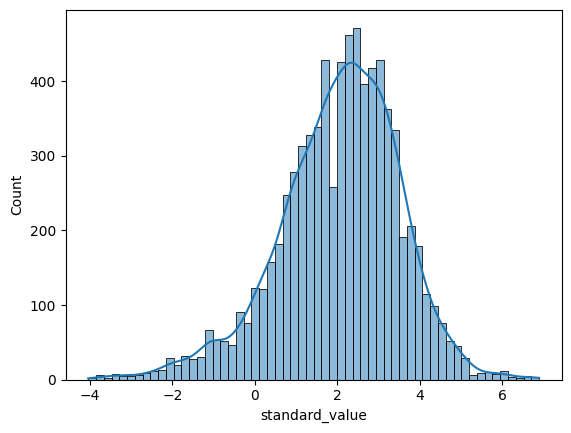

In [51]:
sns.histplot(data=filtered_df, x="standard_value", kde=True)

In [52]:
# Dump to file

filtered_df.to_csv(DATA / f"{readout}_chembl.csv")